<a href="https://colab.research.google.com/github/Abrewst/ML-repo/blob/main/assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
upload = files.upload()


Saving diabetes.csv to diabetes.csv


In [ ]:
from google.colab import files
upload = files.upload()

Saving CancerDataset.ipynb to CancerDataset.ipynb


In [ ]:
import pandas as pd

In [ ]:
import io
df = pd.read_csv(io.BytesIO(upload['diabetes.csv']))

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


===== Sklearn Logistic Regression Results =====
Accuracy : 0.7303
Precision: 0.6905
Recall   : 0.7250
F1 Score : 0.7073


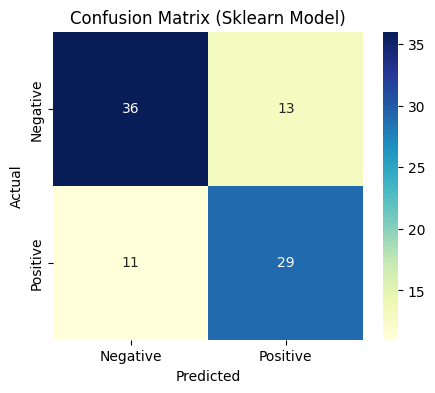


===== Manual Logistic Regression (Gradient Descent) Results =====
Accuracy : 0.7191
Precision: 0.6829
Recall   : 0.7000
F1 Score : 0.6914


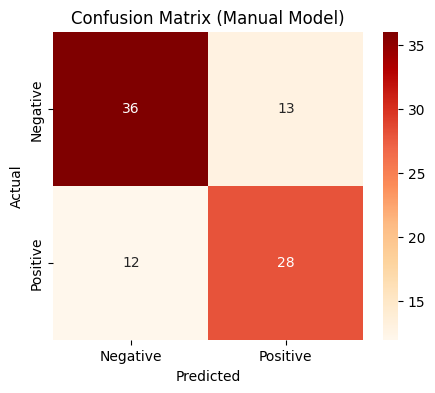

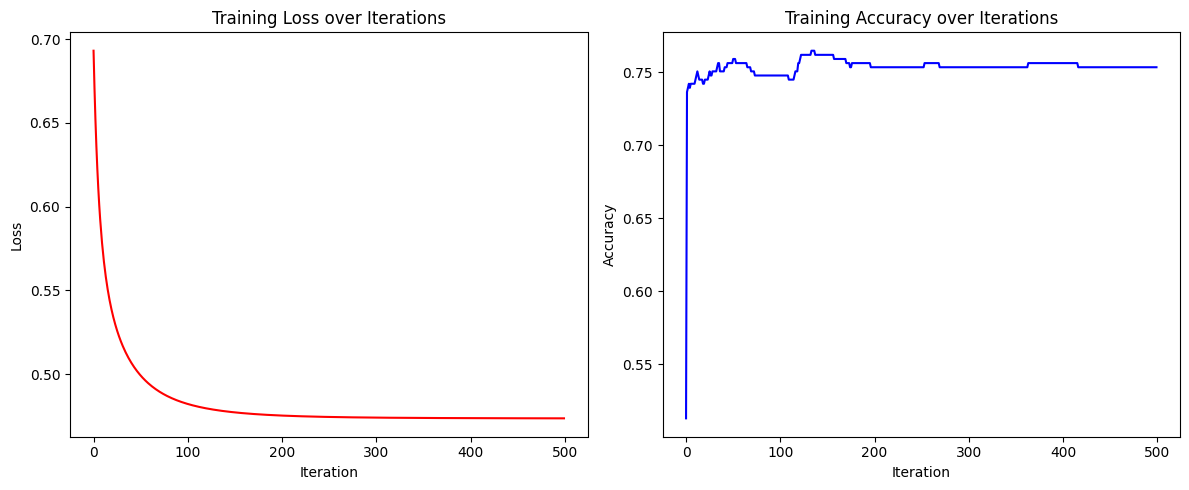


===== Model Comparison =====
      Metric   Sklearn  Manual (GD)
0   Accuracy  0.730337     0.719101
1  Precision  0.690476     0.682927
2     Recall  0.725000     0.700000
3   F1 Score  0.707317     0.691358


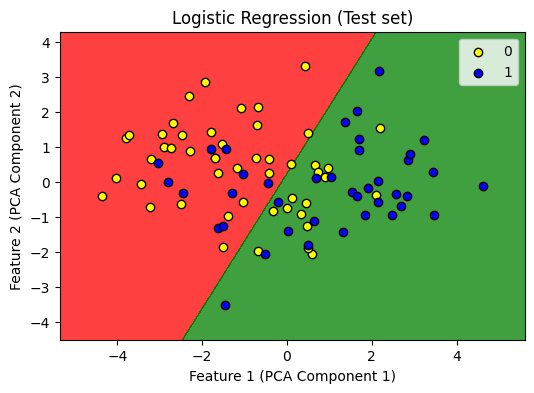

In [ ]:
# ===============================================
# Homework 3 - Problem 1
# Logistic Regression on the Diabetes Dataset
# ===============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap

data = load_diabetes()
X = data.data
y = data.target

y_binary = (y > np.median(y)).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

acc_sklearn = accuracy_score(y_test, y_pred)
prec_sklearn = precision_score(y_test, y_pred)
rec_sklearn = recall_score(y_test, y_pred)
f1_sklearn = f1_score(y_test, y_pred)

print("===== Sklearn Logistic Regression Results =====")
print(f"Accuracy : {acc_sklearn:.4f}")
print(f"Precision: {prec_sklearn:.4f}")
print(f"Recall   : {rec_sklearn:.4f}")
print(f"F1 Score : {f1_sklearn:.4f}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'])
plt.title("Confusion Matrix (Sklearn Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_loss(y_true, y_pred):
    m = len(y_true)
    eps = 1e-15
    return - (1/m) * np.sum(y_true*np.log(y_pred+eps) + (1-y_true)*np.log(1-y_pred+eps))

X_train_bias = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test_bias = np.c_[np.ones((X_test.shape[0], 1)), X_test]

m, n = X_train_bias.shape
theta = np.zeros(n)

alpha = 0.1
epochs = 500

loss_history, acc_history = [], []

for epoch in range(epochs):
    z = np.dot(X_train_bias, theta)
    y_pred_train = sigmoid(z)
    loss = compute_loss(y_train, y_pred_train)
    grad = (1/m) * np.dot(X_train_bias.T, (y_pred_train - y_train))
    theta -= alpha * grad
    y_pred_class = (y_pred_train >= 0.5).astype(int)
    acc = np.mean(y_pred_class == y_train)
    loss_history.append(loss)
    acc_history.append(acc)

y_test_pred_prob = sigmoid(np.dot(X_test_bias, theta))
y_test_pred = (y_test_pred_prob >= 0.5).astype(int)

acc_manual = accuracy_score(y_test, y_test_pred)
prec_manual = precision_score(y_test, y_test_pred)
rec_manual = recall_score(y_test, y_test_pred)
f1_manual = f1_score(y_test, y_test_pred)

print("\n===== Manual Logistic Regression (Gradient Descent) Results =====")
print(f"Accuracy : {acc_manual:.4f}")
print(f"Precision: {prec_manual:.4f}")
print(f"Recall   : {rec_manual:.4f}")
print(f"F1 Score : {f1_manual:.4f}")

cm_manual = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm_manual, annot=True, fmt='d', cmap='OrRd',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'])
plt.title("Confusion Matrix (Manual Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(loss_history, color='red')
plt.title('Training Loss over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Loss')

plt.subplot(1,2,2)
plt.plot(acc_history, color='blue')
plt.title('Training Accuracy over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')

plt.tight_layout()
plt.show()

comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Sklearn': [acc_sklearn, prec_sklearn, rec_sklearn, f1_sklearn],
    'Manual (GD)': [acc_manual, prec_manual, rec_manual, f1_manual]
})
print("\n===== Model Comparison =====")
print(comparison)

pca = PCA(n_components=2)
X_train_2D = pca.fit_transform(X_train)
X_test_2D = pca.transform(X_test)

clf_2D = LogisticRegression(random_state=42)
clf_2D.fit(X_train_2D, y_train)

X_set, y_set = X_test_2D, y_test
X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
    np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01)
)

plt.figure(figsize=(6,4))
plt.contourf(
    X1, X2,
    clf_2D.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha=0.75,
    cmap=ListedColormap(('red', 'green'))
)
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

colors = ['yellow', 'blue']
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0],
        X_set[y_set == j, 1],
        color=colors[i],
        label=j,
        edgecolor='k'

    )

plt.title('Logistic Regression (Test set)')
plt.xlabel('Feature 1 (PCA Component 1)')
plt.ylabel('Feature 2 (PCA Component 2)')
plt.legend()
plt.show()


========== Problem 2(a): Logistic Regression ==========
Accuracy  : 0.9825
Precision : 0.9861
Recall    : 0.9861
F1 Score  : 0.9861


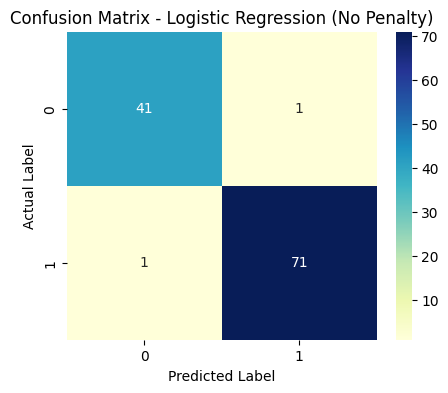

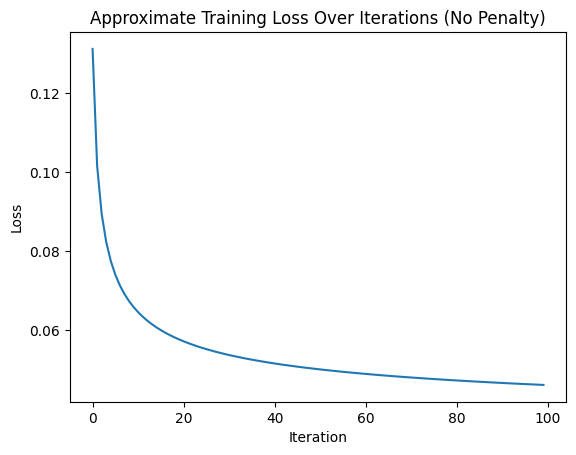

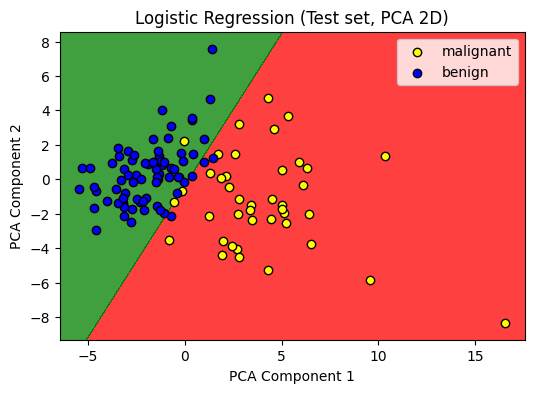


========== Problem 2(b): Logistic Regression with L2 Penalty ==========
Accuracy  : 0.9737
Precision : 0.9726
Recall    : 0.9861
F1 Score  : 0.9793


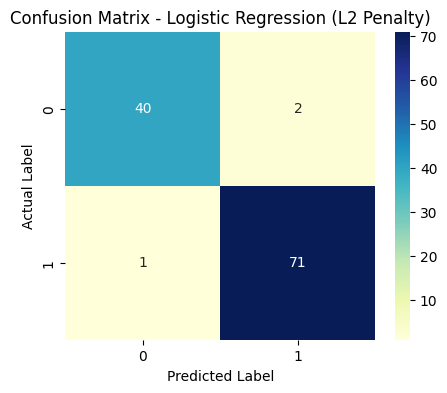

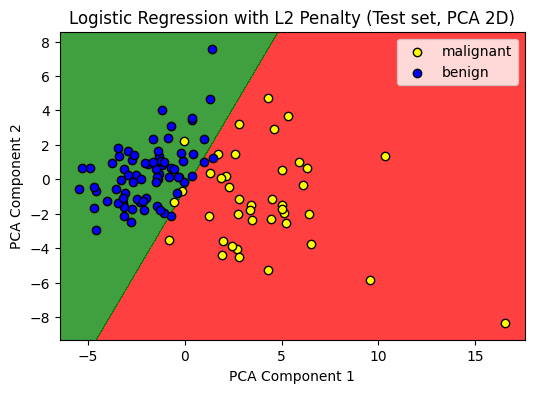


=========== Summary Comparison ===========
               Model  Accuracy  Precision    Recall  F1 Score
0         No Penalty  0.982456   0.986111  0.986111  0.986111
1  L2 Regularization  0.973684   0.972603  0.986111  0.979310


In [ ]:
# =========================================================
# Homework 3 - Problem 2
# Logistic Regression on Breast Cancer Dataset
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap

cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

clf = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

acc = metrics.accuracy_score(y_test, y_pred)
prec = metrics.precision_score(y_test, y_pred)
rec = metrics.recall_score(y_test, y_pred)
f1 = metrics.f1_score(y_test, y_pred)

print("========== Problem 2(a): Logistic Regression ==========")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")

cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu", fmt='g')
plt.title('Confusion Matrix - Logistic Regression (No Penalty)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

try:
    from sklearn.linear_model import SGDClassifier
    sgd_clf = SGDClassifier(loss='log_loss', max_iter=1, learning_rate='constant', eta0=0.01, random_state=42)
    losses = []
    for _ in range(100):
        sgd_clf.partial_fit(X_train, y_train, classes=np.unique(y_train))
        y_score = sgd_clf.decision_function(X_train)
        loss = -np.mean(
            y_train * np.log(1 / (1 + np.exp(-y_score))) +
            (1 - y_train) * np.log(1 - 1 / (1 + np.exp(-y_score)))
        )
        losses.append(loss)
    plt.plot(losses)
    plt.title("Approximate Training Loss Over Iterations (No Penalty)")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.show()
except Exception:
    print("Loss curve plotting skipped (SGD unavailable).")

pca = PCA(n_components=2)
X_train_2D = pca.fit_transform(X_train)
X_test_2D = pca.transform(X_test)

clf_2D = LogisticRegression(random_state=42)
clf_2D.fit(X_train_2D, y_train)

X_set, y_set = X_test_2D, y_test
X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
    np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01)
)
plt.figure(figsize=(6,4))
plt.contourf(
    X1, X2,
    clf_2D.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha=0.75,
    cmap=ListedColormap(('red', 'green'))
)
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
colors = ['yellow', 'blue']
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0],
        X_set[y_set == j, 1],
        color=colors[i],
        label=cancer.target_names[j],
        edgecolor='k'
    )
plt.title('Logistic Regression (Test set, PCA 2D)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.show()

clf_l2 = LogisticRegression(
    penalty='l2', C=0.1, max_iter=1000, solver='lbfgs', random_state=42
)
clf_l2.fit(X_train, y_train)
y_pred_l2 = clf_l2.predict(X_test)

acc2 = metrics.accuracy_score(y_test, y_pred_l2)
prec2 = metrics.precision_score(y_test, y_pred_l2)
rec2 = metrics.recall_score(y_test, y_pred_l2)
f12 = metrics.f1_score(y_test, y_pred_l2)

print("\n========== Problem 2(b): Logistic Regression with L2 Penalty ==========")
print(f"Accuracy  : {acc2:.4f}")
print(f"Precision : {prec2:.4f}")
print(f"Recall    : {rec2:.4f}")
print(f"F1 Score  : {f12:.4f}")

cnf_matrix_l2 = metrics.confusion_matrix(y_test, y_pred_l2)
plt.figure(figsize=(5,4))
sns.heatmap(pd.DataFrame(cnf_matrix_l2), annot=True, cmap="YlGnBu", fmt='g')
plt.title('Confusion Matrix - Logistic Regression (L2 Penalty)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

clf_2D_l2 = LogisticRegression(penalty='l2', C=0.1, random_state=42)
clf_2D_l2.fit(X_train_2D, y_train)

plt.figure(figsize=(6,4))
plt.contourf(
    X1, X2,
    clf_2D_l2.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha=0.75,
    cmap=ListedColormap(('red', 'green'))
)
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0],
        X_set[y_set == j, 1],
        color=colors[i],
        label=cancer.target_names[j],
        edgecolor='k'
    )
plt.title('Logistic Regression with L2 Penalty (Test set, PCA 2D)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.show()

summary = pd.DataFrame({
    'Model': ['No Penalty', 'L2 Regularization'],
    'Accuracy': [acc, acc2],
    'Precision': [prec, prec2],
    'Recall': [rec, rec2],
    'F1 Score': [f1, f12]
})
print("\n=========== Summary Comparison ===========")
print(summary)
